# Research on Apartment Sales Advertisements
We have access to data from Yandex Realty—an archive of housing sale advertisements in Saint Petersburg and neighboring settlements over several years. The task is to learn how to determine the market value of real estate properties. To do this, we conduct an exploratory data analysis (EDA) and identify the parameters that influence property prices. This will make it possible to build an automated system designed to track anomalies and fraudulent activity.

Two types of data are available for each apartment for sale. The first type is entered manually by the user, while the second is generated automatically based on cartographic data. For example, the distance to the city center, the airport, and other locations is automatically retrieved from geo-services. The number of parks and bodies of water is also populated without user intervention.

In [170]:
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns

In [171]:
data = pd.read_csv('real_estate_data (8).csv', sep='\t')

In [172]:
data.head(5)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07T00:00:00,3,2.70,16.0,51.0,8,NaN,...,25.0,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04T00:00:00,1,NaN,11.0,18.6,1,NaN,...,11.0,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20T00:00:00,2,NaN,5.0,34.3,4,NaN,...,8.3,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19T00:00:00,2,3.03,14.0,32.0,13,NaN,...,41.0,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0


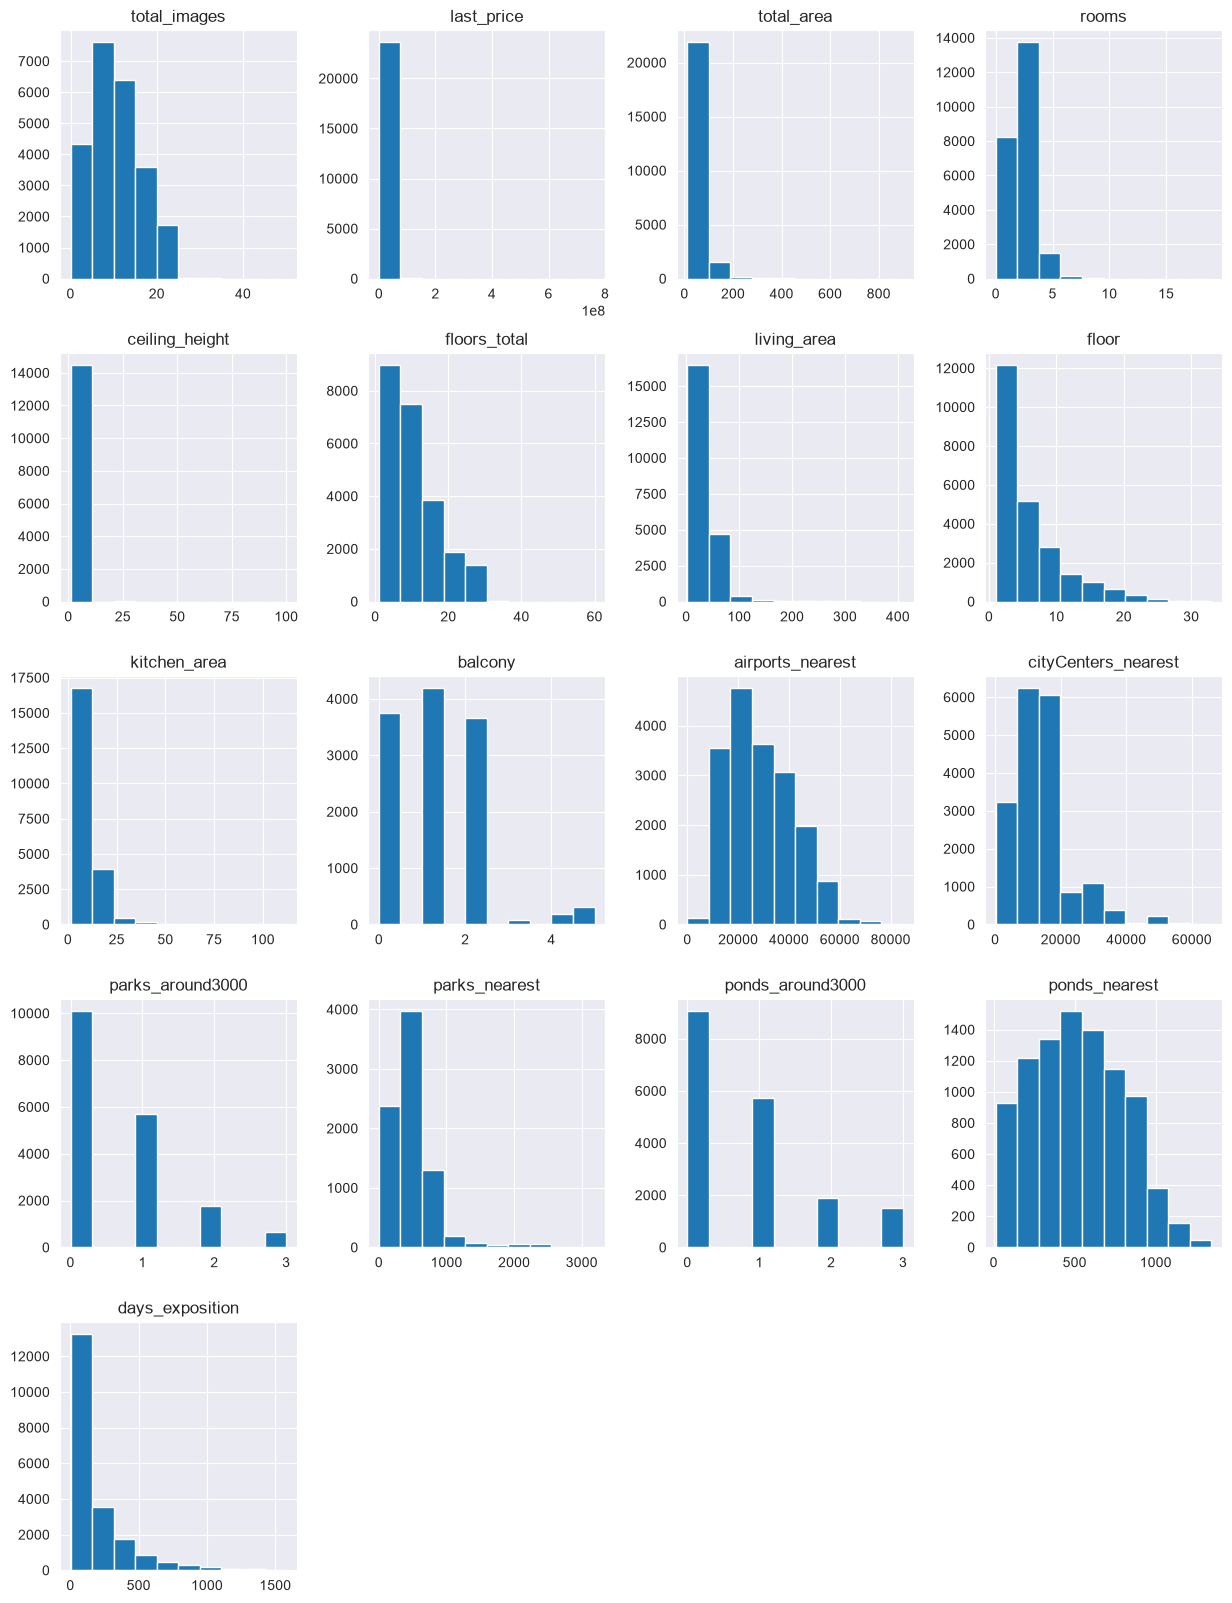

In [173]:
data.hist(figsize=(15, 20))
plt.show()

**<span style="color: green;">Some columns contain anomalously large values atypical of residential real estate, such as property area. These outliers require further processing.
</span>**


In [174]:
data.isnull().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment            20924
studio                      0
open_plan                   0
kitchen_area             2278
balcony                 11519
locality_name              49
airports_nearest         5542
cityCenters_nearest      5519
parks_around3000         5518
parks_nearest           15620
ponds_around3000         5518
ponds_nearest           14589
days_exposition          3181
dtype: int64

In [175]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  str    
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  str    
 15  airports_nearest      18157 no

**<span style="color: green;">Missing values and data types in certain columns will also need to be addressed.
</span>**


### Perform data preprocessing

**2.1 Filling in missing values**

Ceiling height is an optional field in the listing, which could lead to missing values. Missing values in the ceiling_height column will be replaced with the column's median value. The median is well-suited for quantitative data and is robust against outliers.

In [176]:
data['ceiling_height'].fillna(data['ceiling_height'].median(), inplace=True)
#data['floors_total'].fillna(data['floors_total'].median(), inplace=True)
#data['living_area'].fillna(data['living_area'].median(), inplace=True)
#data['kitchen_area'].fillna(data['kitchen_area'].median(), inplace=True)


C:\Users\nelli\AppData\Local\Temp\ipykernel_20056\646096205.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data['ceiling_height'].fillna(data['ceiling_height'].median(), inplace=True)


0        2.70
1        2.65
2        2.65
3        2.65
4        3.03
         ... 
23694    3.70
23695    2.65
23696    2.65
23697    3.00
23698    2.50
Name: ceiling_height, Length: 23699, dtype: float64

To fill in the missing values in living_area and kitchen_area, we will calculate the average ratios of these areas to total_area. Then, for rows with missing values, we will substitute the product of the total area and the corresponding ratio.

In [177]:
living_coef = (data['living_area'] / data['total_area']).mean(skipna=True)
kitchen_coef = (data['kitchen_area'] / data['total_area']).mean(skipna=True)

living_filled = data['total_area'] * living_coef
kitchen_filled = data['total_area'] * kitchen_coef

data['living_area'] = data['living_area'].fillna(living_filled)
data['kitchen_area'] = data['kitchen_area'].fillna(kitchen_filled)

In [178]:
incorrect_lines = data[data['total_area'] < data['living_area'] + data['kitchen_area']].shape[0]
incorrect_lines

123

In [179]:
incorrect_lines / data.shape[0]

0.005190092408962403

In [180]:
data = data.query('(living_area + kitchen_area < total_area)')

In [181]:
incorrect_lines_2 = data[data['total_area'] < data['living_area'] + data['kitchen_area']].shape[0]
incorrect_lines_2

0

The proportion of missing values in the floors_total column is also negligible, so we will drop them.

In [182]:
data['floors_total'].isna().sum()/data.shape[0]

np.float64(0.0036586403471454095)

In [183]:
data = data.dropna(subset=['floors_total'])

Missing values in the parks_around3000 and ponds_around3000 columns will be replaced with 0, as there are most likely no parks or ponds within a 3,000 km radius.

In [184]:
columns_to_fill = ['parks_around3000', 'ponds_around3000']

for column in columns_to_fill:
    data[column] = data[column].fillna(0)

In [185]:
data.isnull().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9037
floors_total                0
living_area                 0
floor                       0
is_apartment            20681
studio                      0
open_plan                   0
kitchen_area                0
balcony                 11397
locality_name              48
airports_nearest         5466
cityCenters_nearest      5443
parks_around3000            0
parks_nearest           15434
ponds_around3000            0
ponds_nearest           14419
days_exposition          3149
dtype: int64

Missing values in the balcony column will be replaced with 0, as they most likely indicate the absence of a balcony.

In [186]:
data['balcony'].fillna(0, inplace=True)

C:\Users\nelli\AppData\Local\Temp\ipykernel_20056\4169825907.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data['balcony'].fillna(0, inplace=True)


0        0.0
1        2.0
2        0.0
3        0.0
4        0.0
        ... 
23694    0.0
23695    0.0
23696    0.0
23697    2.0
23698    0.0
Name: balcony, Length: 23420, dtype: float64

Missing values in the is_apartment column will be replaced with the boolean value False, as the absence of a value likely indicates that the property is not an apartment.

In [187]:
data['is_apartment'].fillna(False, inplace=True)

C:\Users\nelli\AppData\Local\Temp\ipykernel_20056\4221261463.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data['is_apartment'].fillna(False, inplace=True)


0        False
1        False
2        False
3        False
4        False
         ...  
23694    False
23695    False
23696    False
23697    False
23698    False
Name: is_apartment, Length: 23420, dtype: object

The locality_name column contains important information, yet the proportion of rows with missing values is only 0.0021 (0.2%).

In [188]:
data['locality_name'].isna().sum()/data.shape[0]

np.float64(0.002049530315969257)

Rows with missing values in the locality_name column will be dropped. Given that the proportion of such rows is only 0.0021 (0.2%), removing them will not lead to significant data distortion.

In [189]:
data = data.dropna(subset=['locality_name'])

Missing values in the airports_nearest, cityCenters_nearest, pond_nearest, and park_nearest columns will be left as NaN, since it is unlikely that these values can be logically recovered, and filling them with any average value would introduce unwarranted anomalies.

Missing values in the days_exposition column will be left unchanged, as they may indicate that the listing is still active or that the omission was accidental. Replacing these values could distort the results of the analysis.

In [190]:
data.isnull().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9003
floors_total                0
living_area                 0
floor                       0
is_apartment            20648
studio                      0
open_plan                   0
kitchen_area                0
balcony                 11392
locality_name               0
airports_nearest         5458
cityCenters_nearest      5435
parks_around3000            0
parks_nearest           15401
ponds_around3000            0
ponds_nearest           14396
days_exposition          3148
dtype: int64

**2.2 Data type changes**

In [191]:
data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'], format='%Y-%m-%dT%H:%M:%S', errors='coerce')

In [192]:
data['is_apartment'] = data['is_apartment'].astype(bool)

In [193]:
data['balcony'] = data['balcony'].astype('Int64')
data['floors_total'] = data['floors_total'].astype('Int64')
data['ponds_around3000'] = data['ponds_around3000'].astype('Int64')
data['parks_around3000'] = data['parks_around3000'].astype('Int64')

In [194]:
data.info()

<class 'pandas.DataFrame'>
Index: 23372 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23372 non-null  int64         
 1   last_price            23372 non-null  float64       
 2   total_area            23372 non-null  float64       
 3   first_day_exposition  23372 non-null  datetime64[us]
 4   rooms                 23372 non-null  int64         
 5   ceiling_height        14369 non-null  float64       
 6   floors_total          23372 non-null  Int64         
 7   living_area           23372 non-null  float64       
 8   floor                 23372 non-null  int64         
 9   is_apartment          23372 non-null  bool          
 10  studio                23372 non-null  bool          
 11  open_plan             23372 non-null  bool          
 12  kitchen_area          23372 non-null  float64       
 13  balcony               11980 non-

**2.3 Removal of implicit duplicates**

In [195]:
data['locality_name'].nunique()

364

In [196]:
data['locality_name'] = (
    data['locality_name']
    .str.replace('ё', 'е') 
    .replace(
        ['поселок городского типа', 'деревня', 'городской посёлок'], 
        'поселок',  
        regex=True 
    )
)
data['locality_name'].unique()

<StringArray>
[          'Санкт-Петербург',            'поселок Шушары',
 'городской поселок Янино-1',         'поселок Парголово',
            'поселок Мурино',                 'Ломоносов',
                 'Сертолово',                  'Петергоф',
                    'Пушкин',           'поселок Кудрово',
 ...
   'поселок Большое Рейзино',   'поселок Малая Романовка',
       'поселок Дружноселье',            'поселок Пчевжа',
       'поселок Володарское',            'поселок Нижняя',
 'коттеджный поселок Лесное',         'поселок Тихковицы',
    'поселок Борисова Грива',      'поселок Дзержинского']
Length: 324, dtype: str

In [197]:
data['locality_name'].nunique()

324

In [198]:
has_duplicates = data.duplicated().any()

if has_duplicates:
    print("There are explicit duplicates in the table.")
else:
    print("No explicit duplicates were found.")

No explicit duplicates were found.


### Adding new columns to the dataset

In [199]:
data['price_per_meter'] = (data['last_price'] / data['total_area']).round(2)

In [200]:
data['weekday_exposition'] = data['first_day_exposition'].dt.weekday


data['month_exposition'] = data['first_day_exposition'].dt.month

data['year_exposition'] = data['first_day_exposition'].dt.year

In [201]:
def get_floor_type(row):
    if row['floor'] == 1:
        return 'первый'
    elif row['floor'] == row['floors_total']:
        return 'последний'
    else:
        return 'другой'

data['floor_type'] = data.apply(get_floor_type, axis=1)

In [202]:
data['city_center_km'] = (data['cityCenters_nearest'] / 1000).round(0)

**<span style="color: green;">Data Preprocessing Summary</span>**
    
    
- **Identified and handled missing values: some were filled (e.g., balconies replaced with 0), some calculated using average ratios (living area, kitchen), while others were left as structural/informative NaN values.**

- **Adjusted data types for correct analysis: dates were converted to the datetime format, and numeric categories to int and float.**

- **Standardized duplicated locality names into a uniform format.**

- **Removed rows with anomalies (such as cases where the sum of component areas exceeds the total area) as well as full duplicates.**

- **Engineered new features: price per square meter, day of the week, month, and year of publication, floor category, and distance to the city center.**

### Perform exploratory data analysis (EDA)

**<span style="color: blue;">Study of Property Parameters and Outlier Detection
</span>**

**A step-by-step visual analysis was used to identify anomalous values:**

- Histograms were plotted to get a general overview of the feature distribution and initially spot outlying values.
  
- Boxplots were created to determine the boundaries of normal values and the upper threshold point above which outliers may reside.

- Histograms were plotted exclusively for values above the upper bound of the boxplot, which allowed for a closer inspection of the distribution's tail.

- Outliers were determined manually based on visual analysis of the histogram: values that deviated significantly from the main bulk of the data were classified as anomalies.

**1. Living Area**

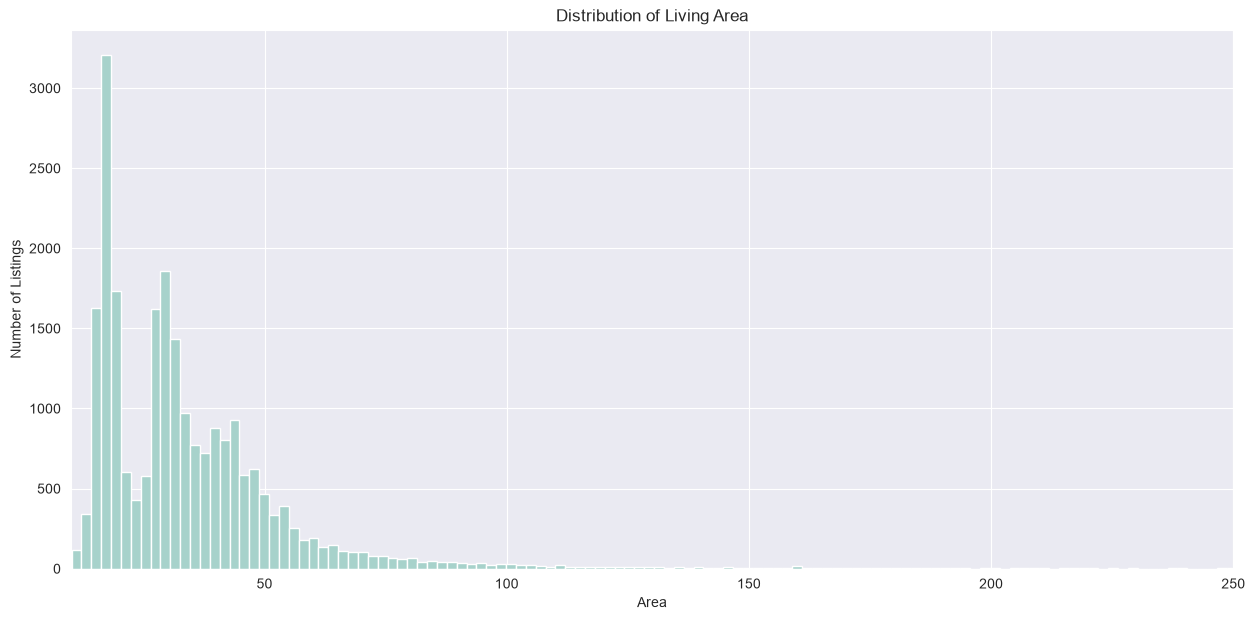

In [203]:
data['living_area'].hist(bins = 200, figsize = (15, 7), color='#A7D2CB')
plt.xlim(10, 250)

plt.title('Distribution of Living Area')
plt.xlabel('Area') 
plt.ylabel('Number of Listings')
plt.show()

**<span style="color: green;">The living area histogram shows a skewed distribution with a long right tail, which may indicate the presence of outliers. The bulk of the values is concentrated in the 20 to 100 $m^2$ range, which corresponds to typical residential properties.
</span>**

<Axes: >

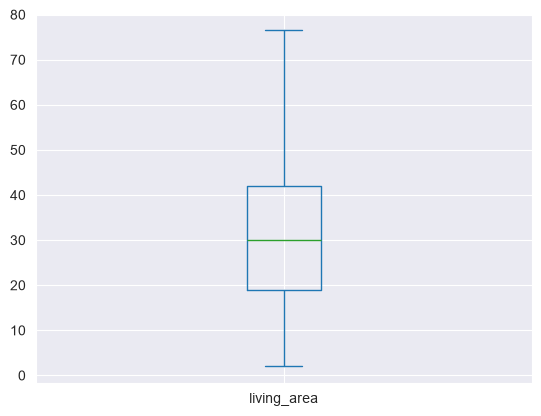

In [204]:
data['living_area'].plot(kind='box', showfliers=False)

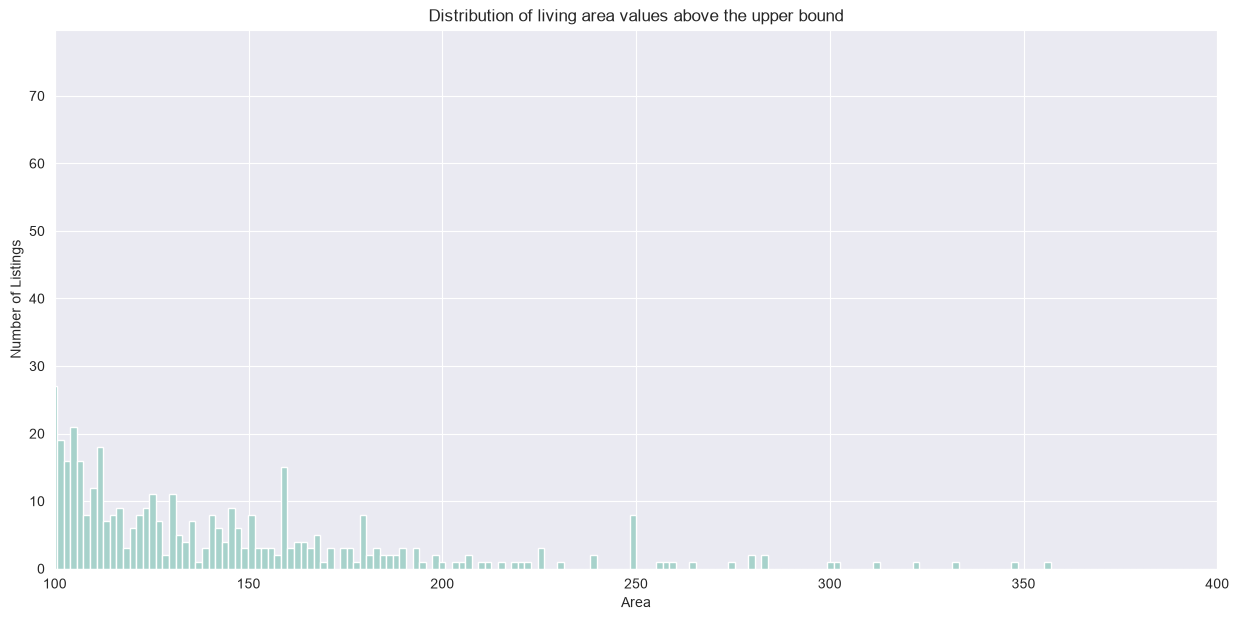

In [205]:
data[data['living_area'] > 70]['living_area'].hist(bins = 200, figsize = (15, 7), color='#A7D2CB')
plt.xlim(100, 400)

plt.title('Distribution of living area values above the upper bound')
plt.xlabel('Area') 
plt.ylabel('Number of Listings')
plt.show()

In [206]:
data['living_area'].describe()

count    23372.000000
mean        34.498962
std         22.293247
min          2.000000
25%         19.000000
50%         30.000000
75%         42.000000
max        409.700000
Name: living_area, dtype: float64

Beyond the value of 200  , the distribution becomes too scattered, which may indicate outliers. Therefore, we will restrict the living area values to the range between 10 and 200   and create a new table, filtered_data, to which we will add the cleaned columns.

In [207]:
filtered_data = data.query('10 < living_area <= 200')

**2. Total area**

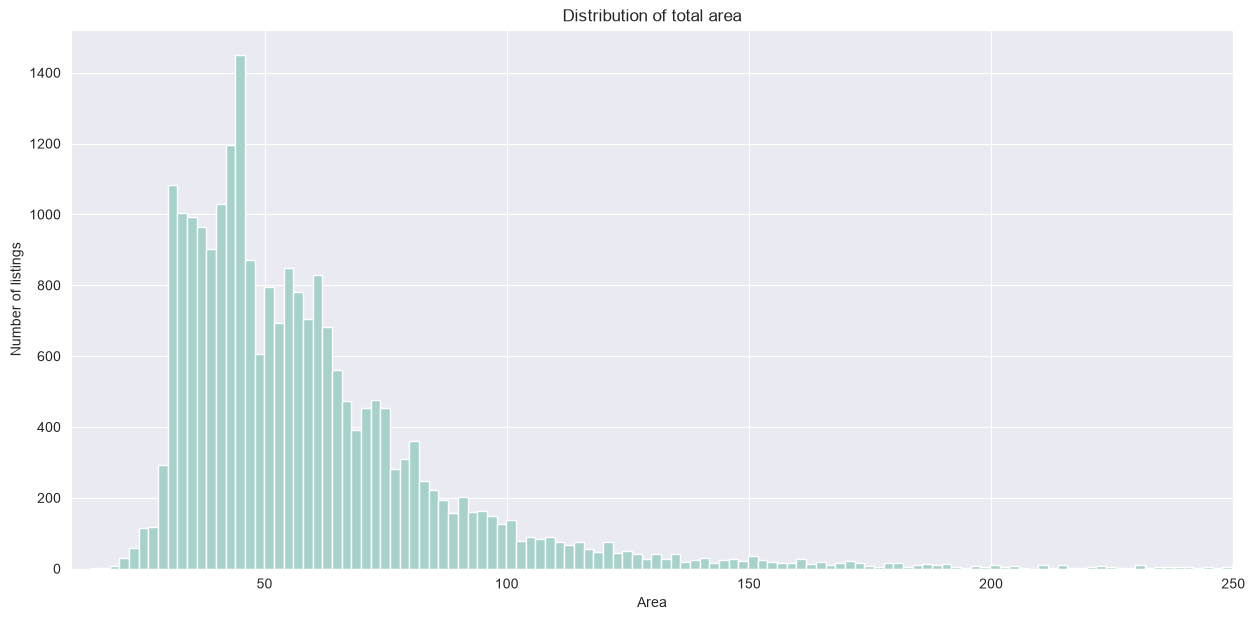

In [208]:
filtered_data['total_area'].hist(bins = 200, figsize = (15, 7), color='#A7D2CB')
plt.xlim(10, 250)

plt.title('Distribution of total area')
plt.xlabel('Area') 
plt.ylabel('Number of listings')
plt.show()

**<span style="color: green;">The total area histogram shows a skewed distribution, again with a long right tail, which may indicate the presence of outliers.
</span>**

<Axes: >

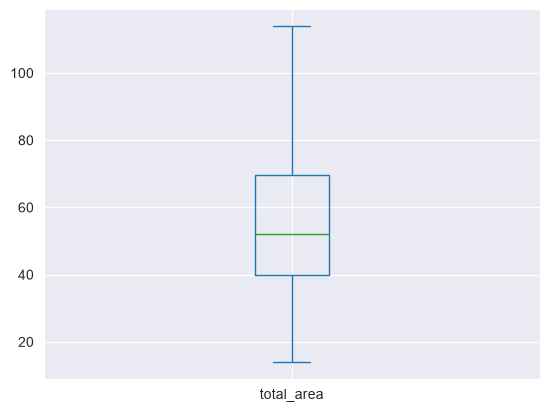

In [209]:
filtered_data['total_area'].plot(kind='box', showfliers=False)

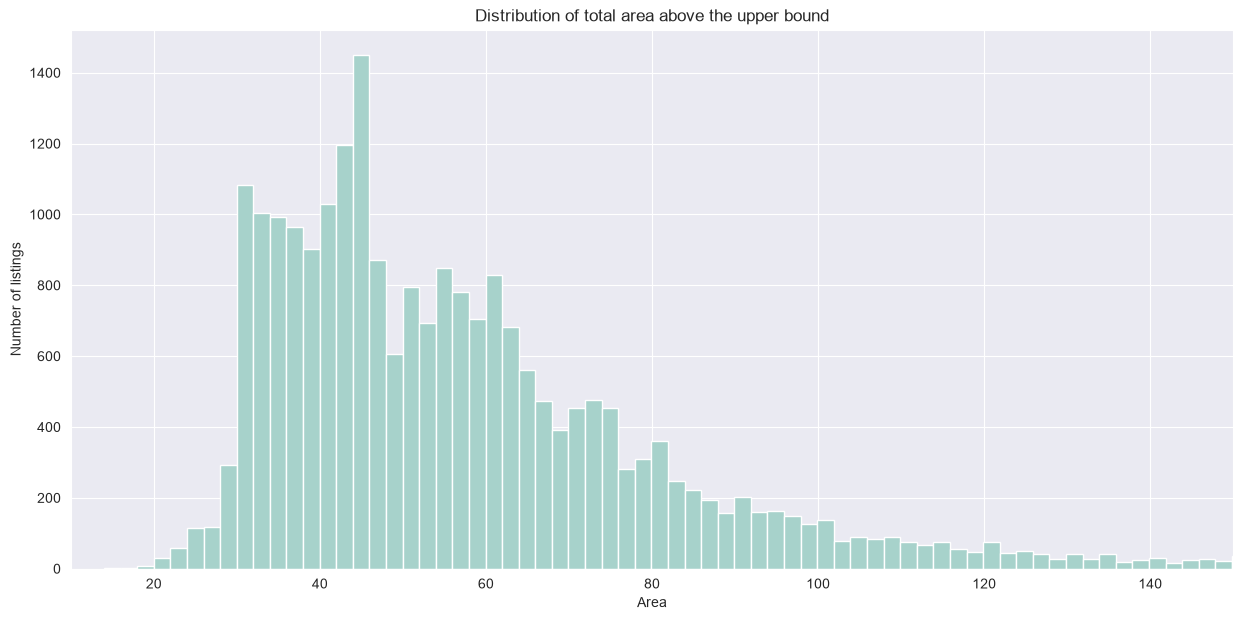

In [210]:
filtered_data['total_area'].hist(bins = 200, figsize = (15, 7), color='#A7D2CB')
plt.xlim(10, 150)

plt.title('Distribution of total area above the upper bound')
plt.xlabel('Area') 
plt.ylabel('Number of listings')
plt.show()

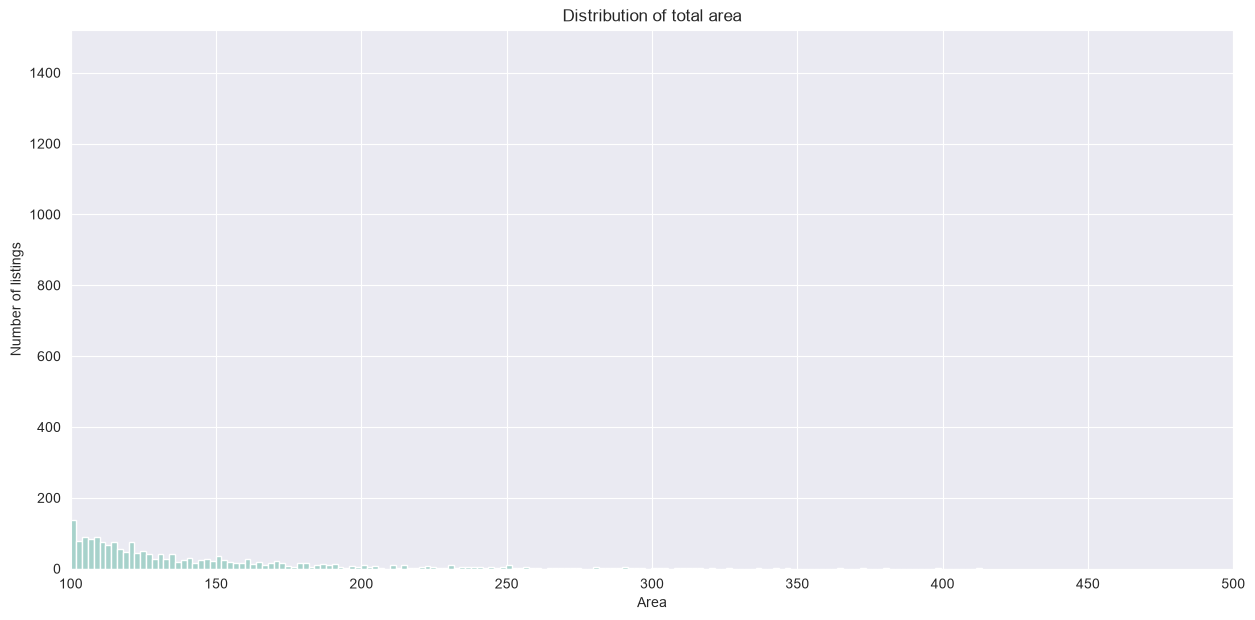

In [211]:

filtered_data['total_area'].hist(bins = 200, figsize = (15, 7), color='#A7D2CB')
plt.xlim(100, 500)

plt.title('Distribution of total area')
plt.xlabel('Area') 
plt.ylabel('Number of listings')
plt.show()

In [212]:
filtered_data['total_area'].describe()

count    23269.000000
mean        59.777019
std         31.563080
min         14.000000
25%         40.000000
50%         52.000000
75%         69.610000
max        413.500000
Name: total_area, dtype: float64

We are restricting the total area values to the range from 20 to 250  м².

In [213]:
filtered_data = data.query('20 < total_area <= 250')

**3. Kitchen area**

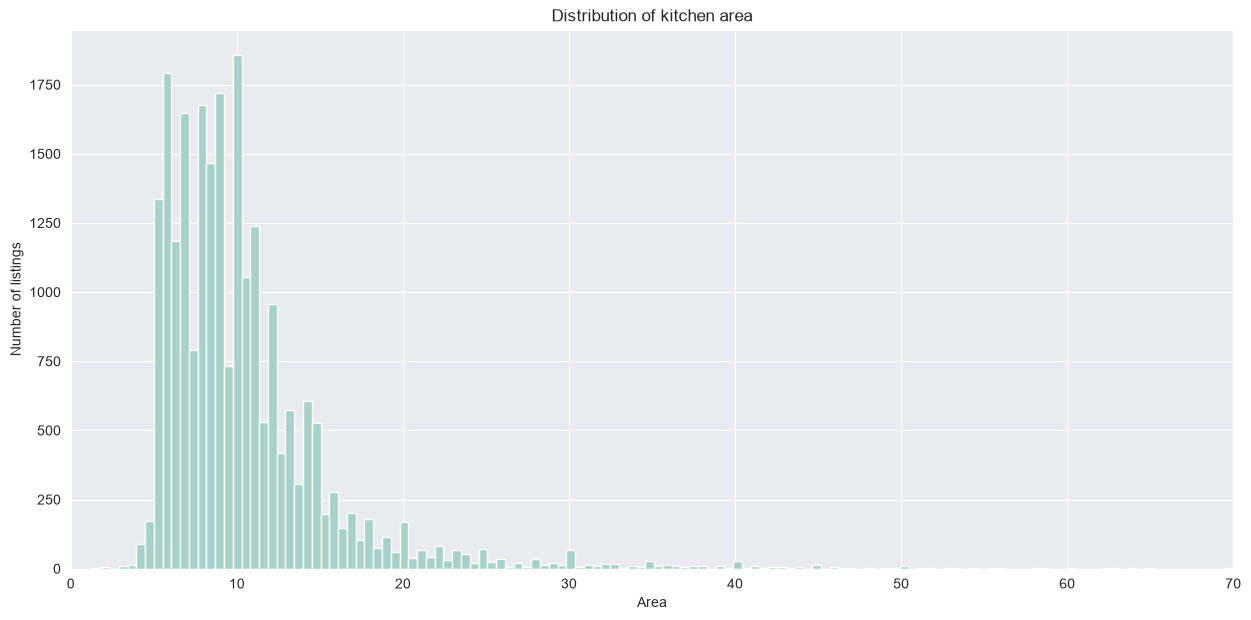

In [214]:
filtered_data['kitchen_area'].hist(bins = 200, figsize = (15, 7), color='#A7D2CB')
plt.xlim(0, 70)

plt.title('Distribution of kitchen area')
plt.xlabel('Area') 
plt.ylabel('Number of listings')
plt.show()

**<span style="color: green;">The kitchen area histogram shows a distribution with a peak around 10 m², which is typical for an average kitchen, and has a right tail with anomalously large values. Outliers can be associated with both luxury real estate and data entry errors. 
</span>**

<Axes: >

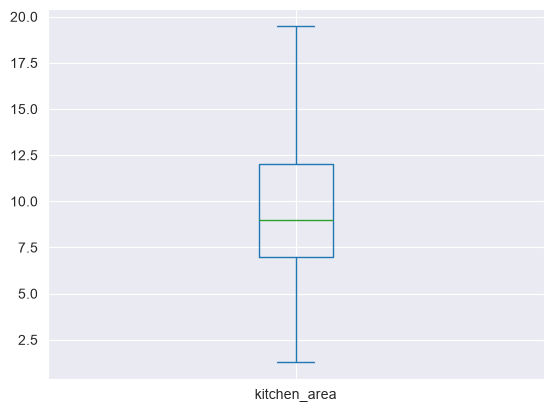

In [215]:
filtered_data['kitchen_area'].plot(kind='box', showfliers=False)

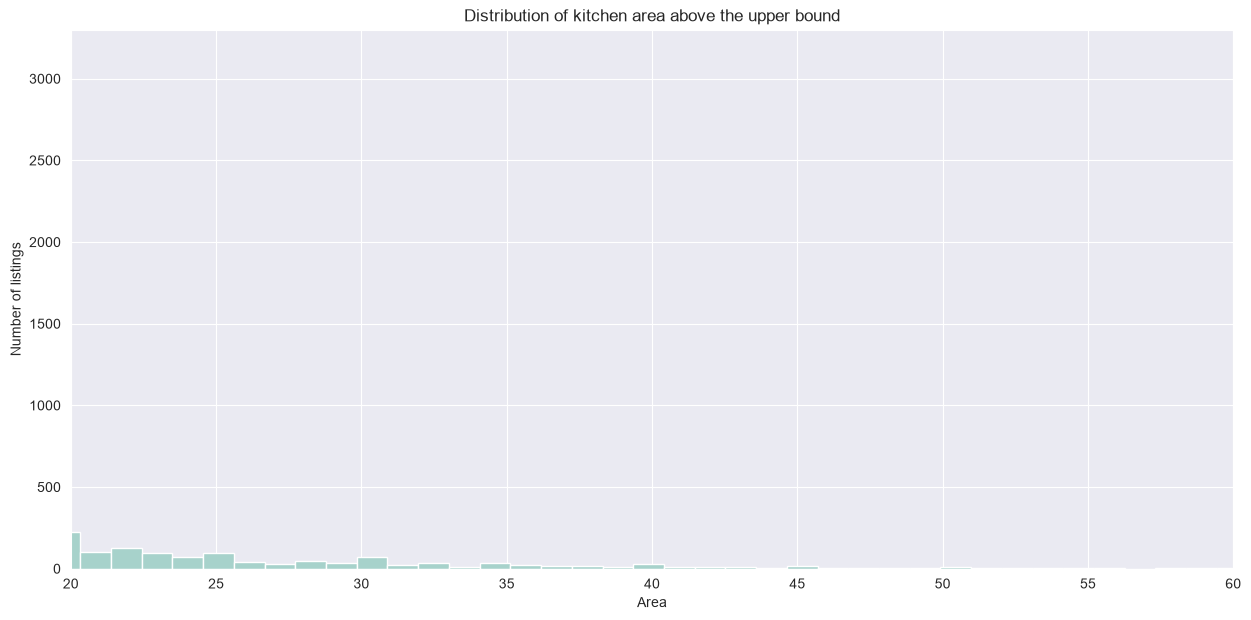

In [216]:
filtered_data['kitchen_area'].hist(bins = 100, figsize = (15, 7), color='#A7D2CB')
plt.xlim(20, 60)

plt.title('Distribution of kitchen area above the upper bound')
plt.xlabel('Area') 
plt.ylabel('Number of listings')
plt.show()

In [217]:
filtered_data['kitchen_area'].describe()

count    23233.000000
mean        10.412368
std          5.525232
min          1.300000
25%          7.000000
50%          9.000000
75%         12.000000
max        107.000000
Name: kitchen_area, dtype: float64

We are restricting the kitchen area from 3 to 40 m².

In [218]:
filtered_data = filtered_data.query('3 < kitchen_area <= 40')

**4. Amount of rooms**

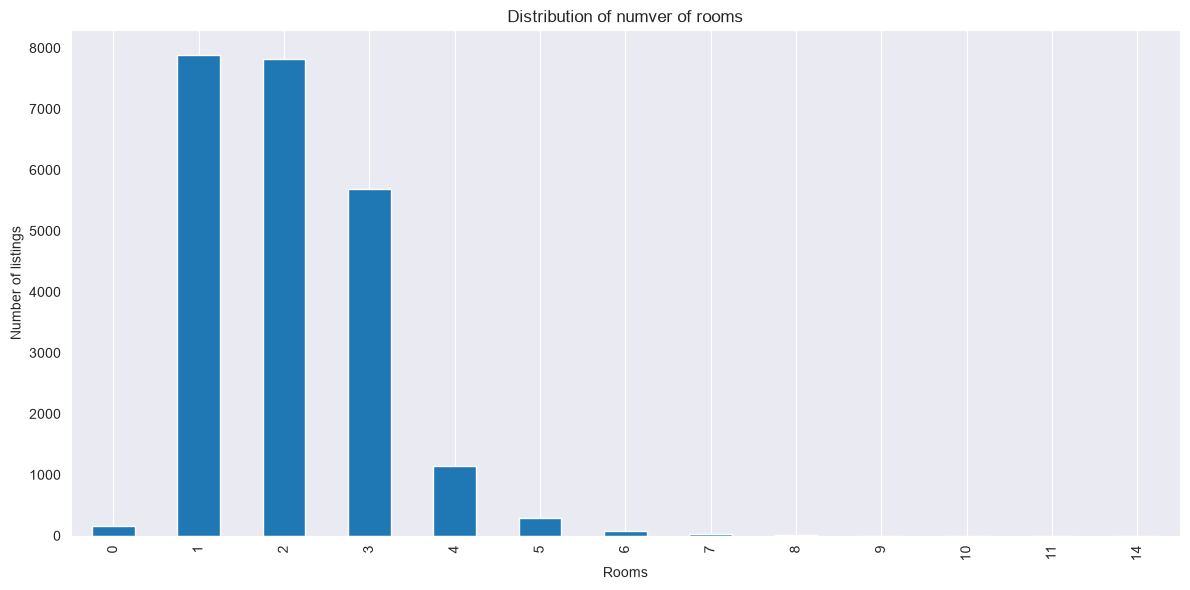

In [219]:
filtered_data['rooms'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(12, 6),
    title='Distribution of numver of rooms')
plt.xlabel('Rooms')
plt.ylabel('Number of listings')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

**<span style="color: green;">**<span style="color: green;">The majority of apartments are assigned between 1 and 3 rooms, which is typical for standard residential real estate.

</span>**

<Axes: >

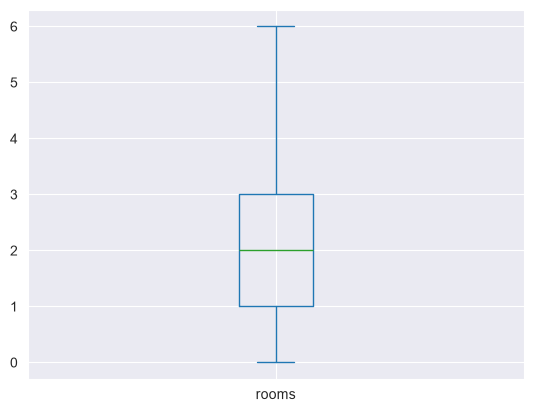

In [220]:
filtered_data['rooms'].plot(kind='box', showfliers=False)

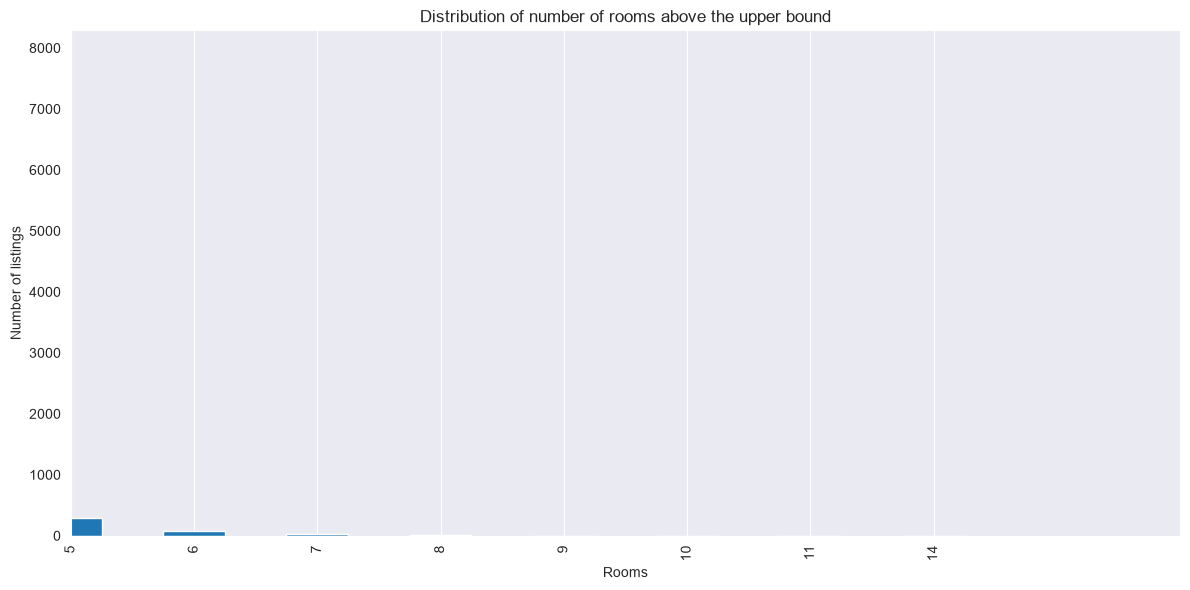

In [221]:
filtered_data['rooms'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(12, 6),
    title='Distribution of number of rooms above the upper bound')
plt.xlim(5, 14)
plt.xlabel('Rooms')
plt.ylabel('Number of listings')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [222]:
filtered_data['rooms'].describe()

count    23113.000000
mean         2.050621
std          1.021548
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         14.000000
Name: rooms, dtype: float64

We are restricting the number of rooms to a range from 1 to 6.

In [223]:
filtered_data=filtered_data.query('rooms < 7')

**5. Ceiling height**

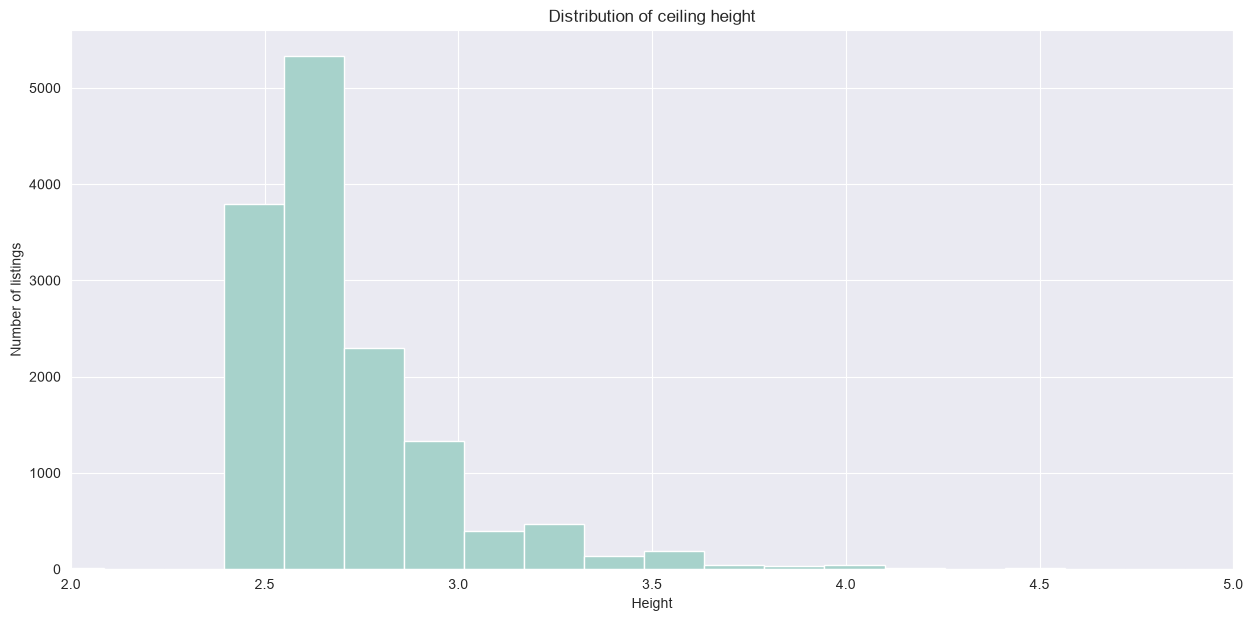

In [224]:
filtered_data['ceiling_height'].hist(bins = 200, figsize = (15, 7), color='#A7D2CB')
plt.xlim(2, 5)

plt.title('Distribution of ceiling height')
plt.xlabel('Height') 
plt.ylabel('Number of listings')
plt.show()

<Axes: >

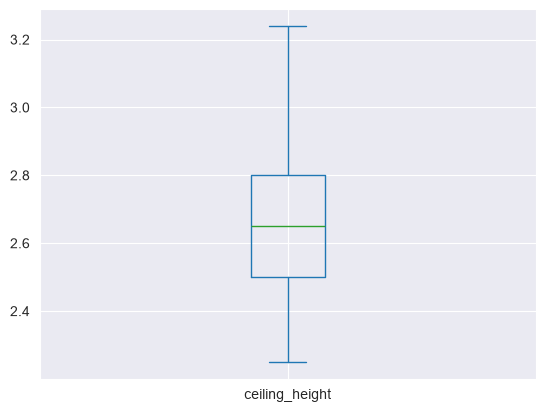

In [225]:
filtered_data['ceiling_height'].plot(kind='box', showfliers=False)

**<span style="color: green;">The boxplot helps to visually assess the middle range of ceiling height values — from 2.45 to 2.85 meters
</span>**

In [226]:
filtered_data['ceiling_height'].describe()

count    14166.000000
mean         2.753927
std          0.931295
min          1.000000
25%          2.500000
50%          2.650000
75%          2.800000
max         32.000000
Name: ceiling_height, dtype: float64

We are restricting ceiling heights to the range from 2.4 to 3.5 meters.

In [227]:
filtered_data = filtered_data.query('2.4 < ceiling_height < 3.5')

**6. Floor type**

<Axes: >

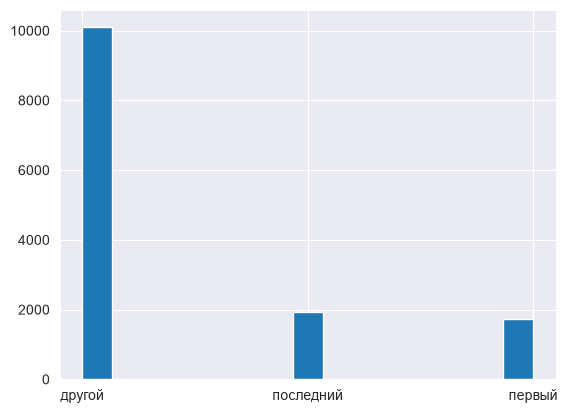

In [228]:
filtered_data['floor_type'].hist(bins=15)

**<span style="color: green;"> The histogram clearly shows that the majority of apartments for sale fall into the 'other' category rather than the 'first' or 'last' floor. The data looks plausible — the 'other' category is broader and therefore includes more apartments.
</span>**

**7. Total number of floors**

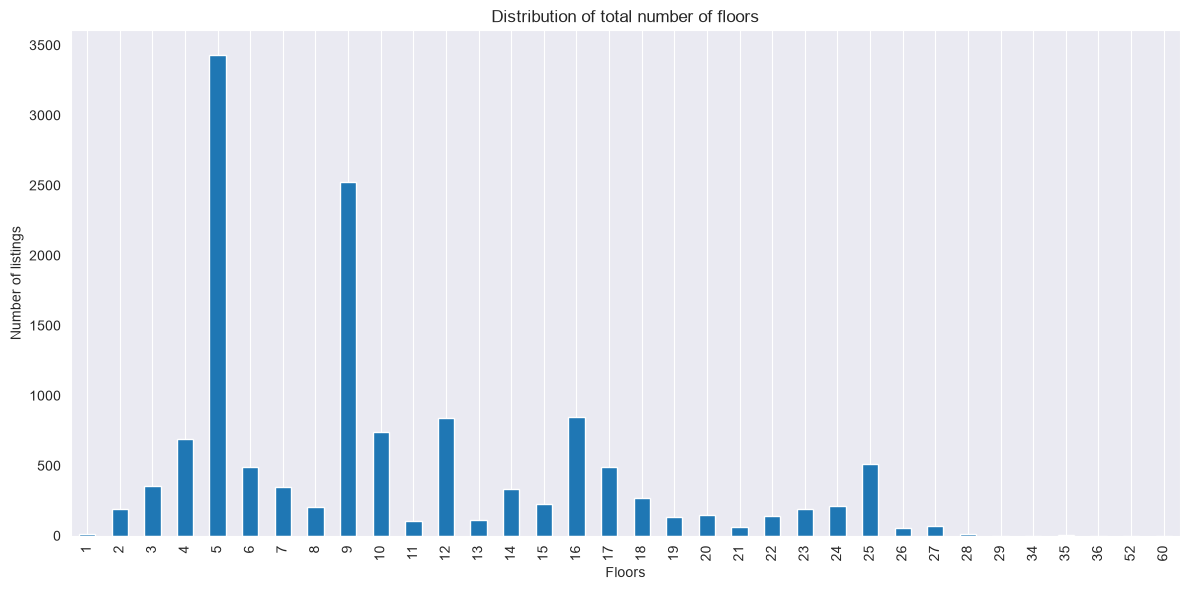

In [229]:
filtered_data['floors_total'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(12, 6),
    title='Distribution of total number of floors')

plt.xlabel('Floors')
plt.ylabel('Number of listings')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

**<span style="color: green;"> Based on the histogram, we can say that the majority of apartments are located in buildings with a floor count ranging from 5 to 10, with peaks at 5 and 9 floors, which is typical for standard residential housing.
</span>**

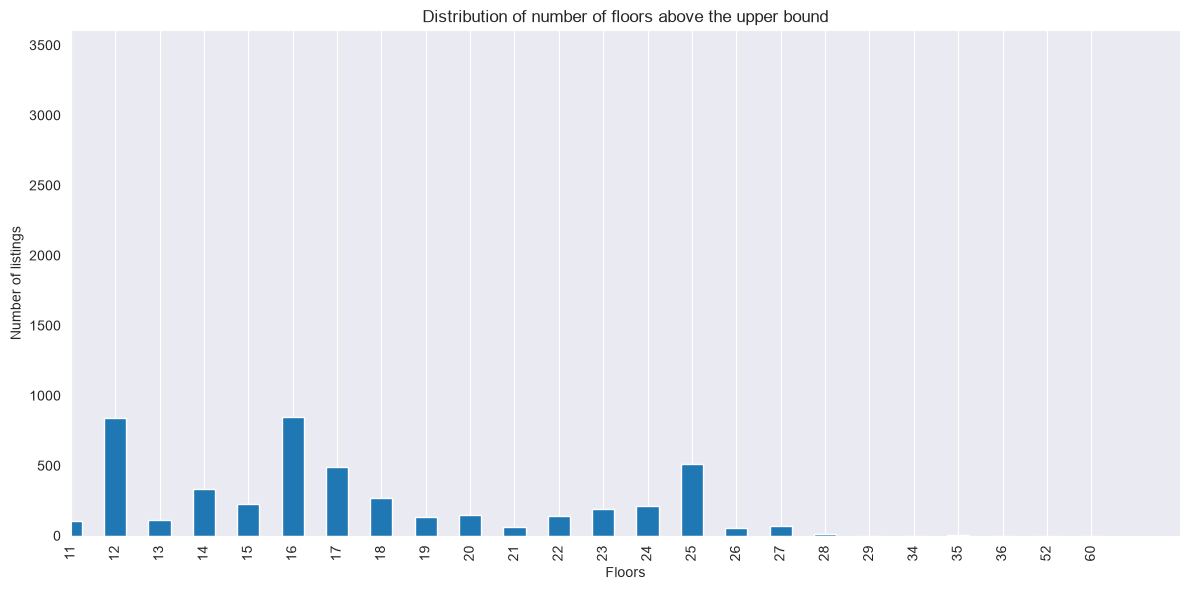

In [230]:
filtered_data['floors_total'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(12, 6),
    title='Distribution of number of floors above the upper bound')
plt.xlim(10, 35)
plt.xlabel('Floors')
plt.ylabel('Number of listings')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [231]:
filtered_data['floors_total'].describe()

count      13751.0
mean     10.341648
std       6.211725
min            1.0
25%            5.0
50%            9.0
75%           14.0
max           60.0
Name: floors_total, dtype: Float64

The values in floors_total are within reasonable limits (2–36); there are likely no outliers, so no filtering is required.

**8. Distance from the city center**

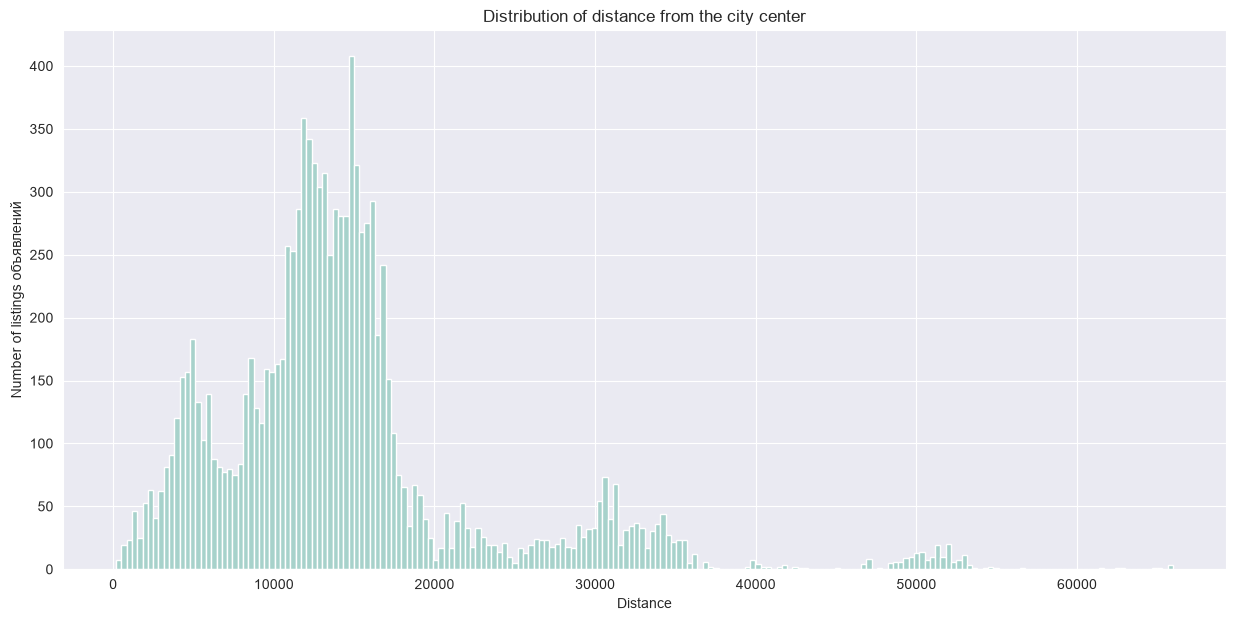

In [232]:
filtered_data['cityCenters_nearest'].hist(bins = 200, figsize = (15, 7), color='#A7D2CB')

plt.title('Distribution of distance from the city center')
plt.xlabel('Distance') 
plt.ylabel('Number of listings объявлений')
plt.show()

**<span style="color: green;"> A significant portion of the apartments are located at a distance of 10,000 to 18,000 meters from the city center, which is within the normal range, with a peak at 15,000 meters. However, suspiciously large values are observed at the tail of the histogram. The greater the distance, the more likely it is that the given property is located in another settlement.
</span>**

<Axes: >

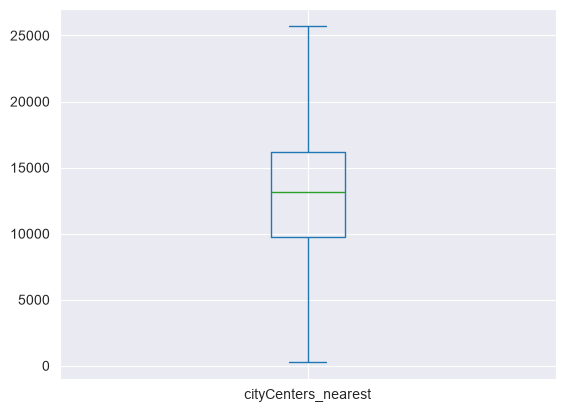

In [233]:
filtered_data['cityCenters_nearest'].plot(kind='box', showfliers=False)

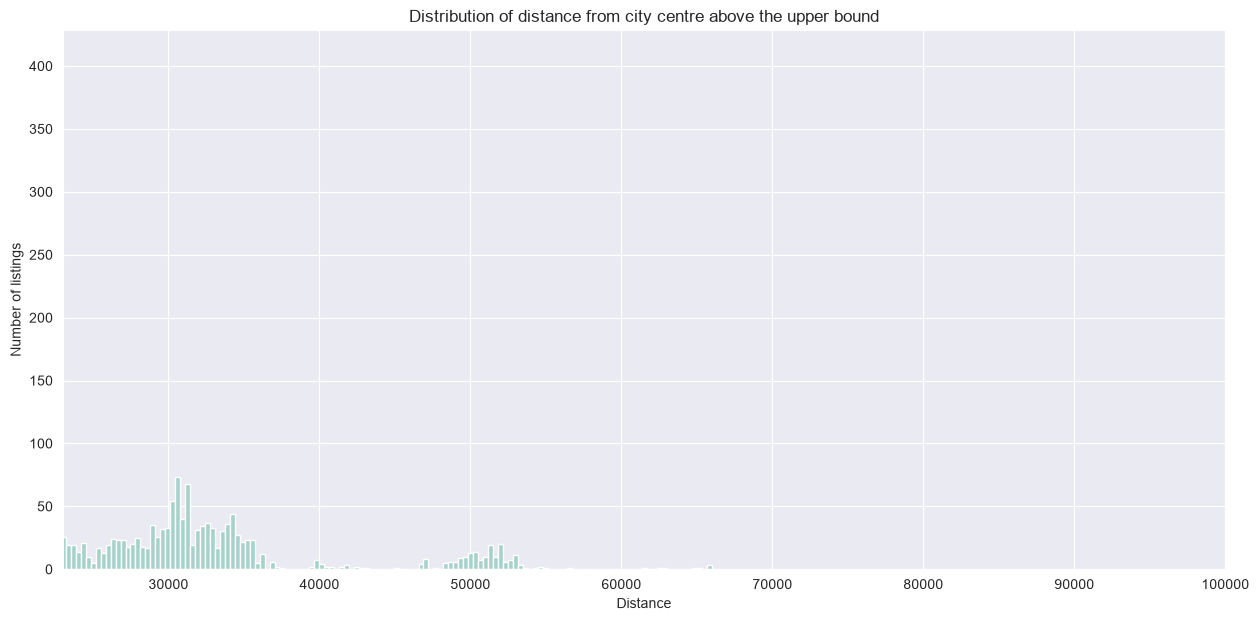

In [234]:
filtered_data['cityCenters_nearest'].hist(bins = 200, figsize = (15, 7), color='#A7D2CB')
plt.xlim(23000, 100000)
plt.title('Distribution of distance from city centre above the upper bound')
plt.xlabel('Distance') 
plt.ylabel('Number of listings')
plt.show()

In [235]:
filtered_data['cityCenters_nearest'].describe()

count    10900.000000
mean     14442.640092
std       8659.714213
min        181.000000
25%       9782.000000
50%      13165.500000
75%      16167.000000
max      65968.000000
Name: cityCenters_nearest, dtype: float64

**What we can see:**

- Median: ~13 km from the center — normal.

- 75% of apartments: up to ~16 km.

- Maximum: almost 50 km — unlikely for city limits (could be a GPS error or a remote suburb).

Let's restrict the distance to 40,000 meters.



In [236]:
filtered_data = filtered_data.query('cityCenters_nearest < 40000')


**9. Distance from the nearest park**

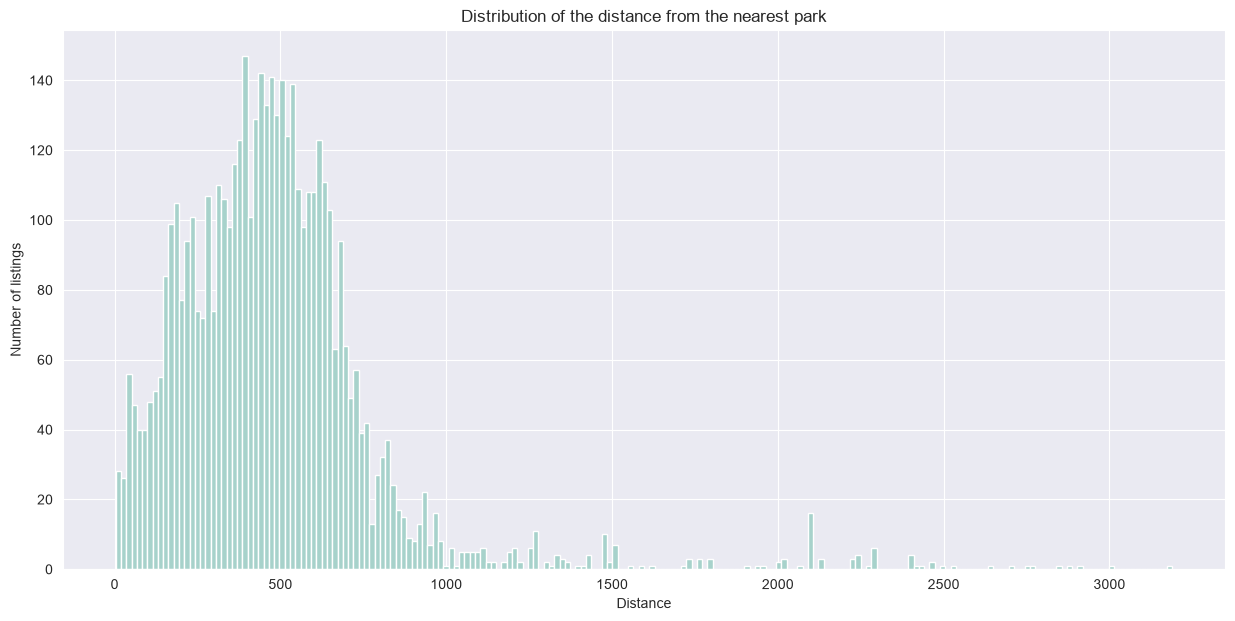

In [237]:
filtered_data['parks_nearest'].hist(bins = 200, figsize = (15, 7), color='#A7D2CB')
plt.title('Distribution of the distance from the nearest park')
plt.xlabel('Distance') 
plt.ylabel('Number of listings')
plt.show()

**<span style="color: green;">The histogram shows that a significant part of the apartments are located near a park, with a peak at a distance of 500 meters. There are also significantly larger values up to 3,000 meters, which indicates that the nearest park to the apartment is quite far away.
</span>**

**10. Price**

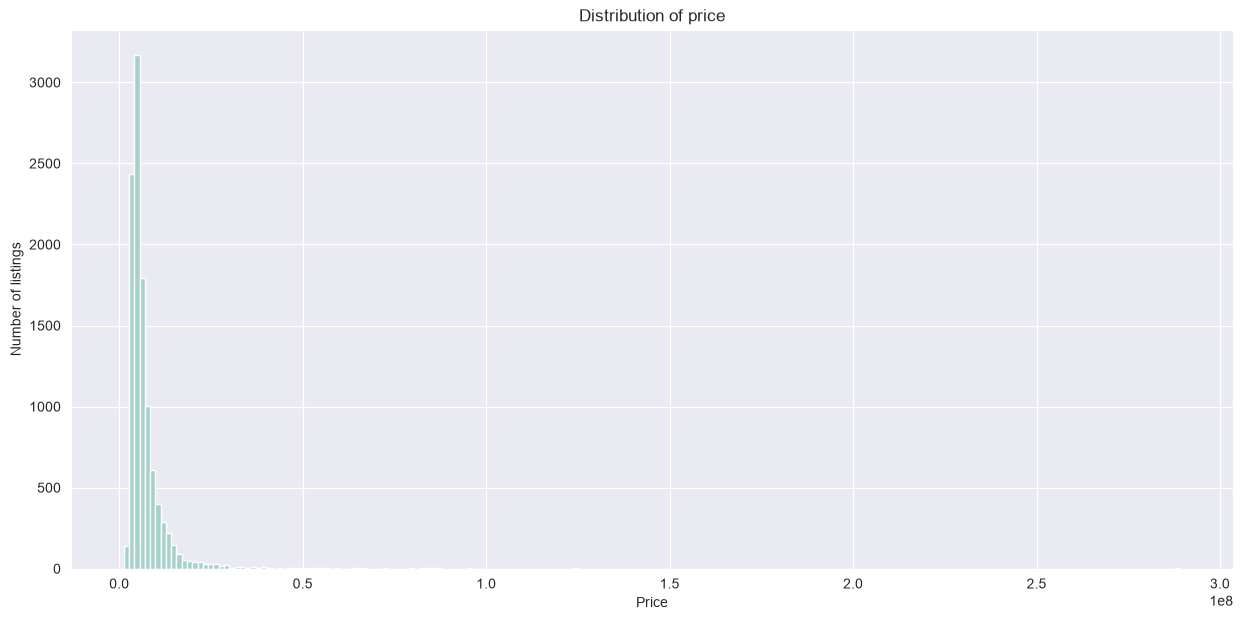

In [238]:
filtered_data['last_price'].hist(bins = 200, figsize = (15, 7), color='#A7D2CB')
plt.title('Distribution of price')
plt.xlabel('Price') 
plt.ylabel('Number of listings')
plt.show()

<Axes: >

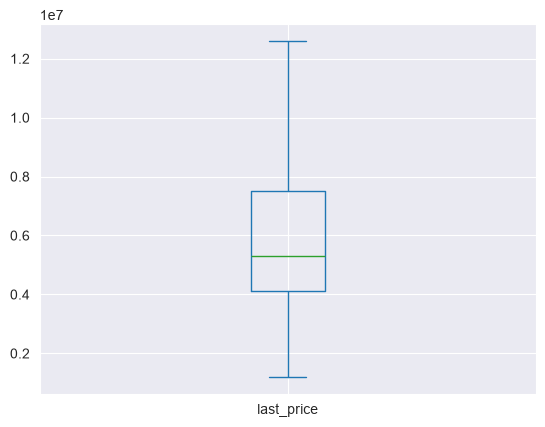

In [239]:
filtered_data['last_price'].plot(kind='box', showfliers=False)


**<span style="color: green;">The boxplot shows that apartment prices range from 2,000,000 to 12,000,000 rubles, with a median value around 4,000,000 rubles.
</span>**

In [240]:
filtered_data['last_price'].describe()

count    1.069900e+04
mean     6.924364e+06
std      6.339071e+06
min      1.200000e+06
25%      4.100000e+06
50%      5.300000e+06
75%      7.500000e+06
max      2.892384e+08
Name: last_price, dtype: float64

Setting a price limit of up to 50,000,000 rubles.

In [241]:
filtered_data = filtered_data.query('last_price < 50000000')

**11. How many days the listing was posted**

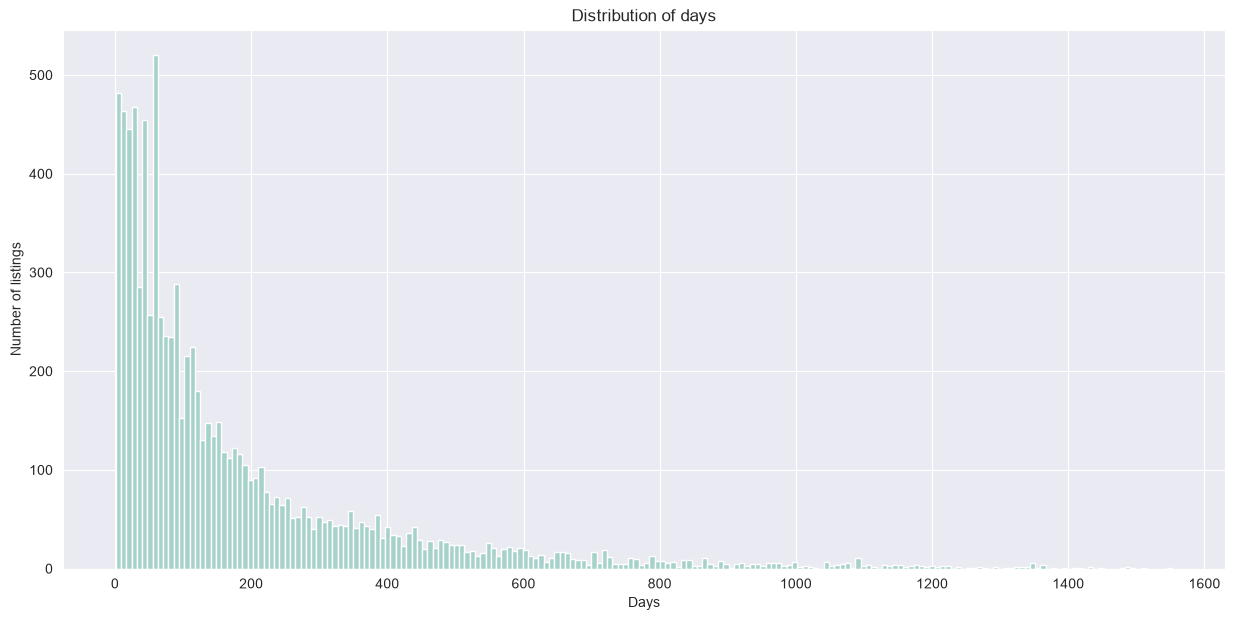

In [242]:
filtered_data['days_exposition'].hist(bins = 200, figsize = (15, 7), color='#A7D2CB')
plt.title('Distribution of days')
plt.xlabel('Days') 
plt.ylabel('Number of listings')
plt.show()

**<span style="color: green;">The apartment sales histogram shows a concentration on the left, with a peak around 100 days. This leads to the conclusion that the majority of apartments were sold within the first few months, while the sales of a small number of properties stretched over several years.
</span>**

In [243]:
days_mean = int(filtered_data['days_exposition'].mean().round(0))
days_median = int(filtered_data['days_exposition'].median().round(0))
print(f"Mean: {days_mean}, Median: {days_median}")

Mean: 184, Median: 98


In [244]:
filtered_data['days_exposition'].describe()

count    8970.000000
mean      184.290078
std       225.654560
min         1.000000
25%        42.000000
50%        98.000000
75%       234.000000
max      1553.000000
Name: days_exposition, dtype: float64

**<span style="color: blue;">Analysis of listing duration showed that:
</span>**

- The median selling time is 98 days, meaning half of the apartments were sold within three months.


- The mean value is 184 days, which is significantly higher than the median — this indicates the presence of individual cases with very long selling times that pull the average up.


- 25% of apartments were sold in 42 days or less — such cases can be considered fast sales.


- 75% of apartments took no longer than 234 days to sell — anything beyond this period can be considered an unusually protracted sale.




**<span style="color: green;">Thus:
</span>**


- **Fast sale — up to 42 days,**

- **Typical — from 42 to 234 days,**

- **Unusually long — more than 234 days.**

**Impact of factors on the total price**

In [245]:
filtered_data[['last_price', 'total_area', 'living_area', 'kitchen_area', 'rooms', 'weekday_exposition', 'month_exposition', 'year_exposition']].corr()


,last_price,total_area,living_area,kitchen_area,rooms,weekday_exposition,month_exposition,year_exposition
last_price,1.000000,0.798855,0.702651,0.602099,0.499699,-0.018296,0.011207,-0.050911
total_area,0.798855,1.000000,0.935833,0.611007,0.784685,-0.013875,0.015889,-0.113418
living_area,0.702651,0.935833,1.000000,0.401416,0.865178,-0.007854,0.007544,-0.095931
kitchen_area,0.602099,0.611007,0.401416,1.000000,0.259372,-0.018162,0.014764,-0.086074
rooms,0.499699,0.784685,0.865178,0.259372,1.000000,-0.001284,0.004540,-0.064719
weekday_exposition,-0.018296,-0.013875,-0.007854,-0.018162,-0.001284,1.000000,-0.011236,0.003506
month_exposition,0.011207,0.015889,0.007544,0.014764,0.004540,-0.011236,1.000000,-0.307191
year_exposition,-0.050911,-0.113418,-0.095931,-0.086074,-0.064719,0.003506,-0.307191,1.000000


**<span style="color: green;">From the first row of the correlation table, it is clear that there is a strong positive correlation between price and total area, as well as a weaker relationship between price and living area. There is also a moderate correlation between price, kitchen area, and room count. The relationship with other factors is minimal. Let's plot visual graphs for these parameters.
</span>**


**1. Total area**

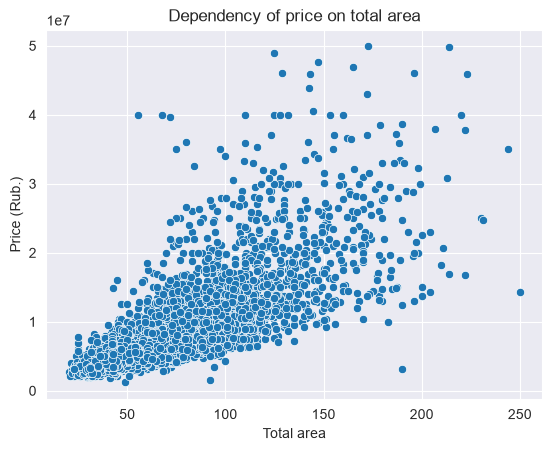

In [246]:
sns.scatterplot(data=filtered_data, x='total_area', y='last_price')
plt.title('Dependency of price on total area')
plt.xlabel('Total area')
plt.ylabel('Price (Rub.)')
plt.grid(True)
plt.show()

**<span style="color: green;">The chart shows an overall positive trend: the larger the apartment’s area, the higher its price. The majority of properties are concentrated in the range of up to 100 m² and up to 10 million rubles. 
</span>**

**2. Living area **

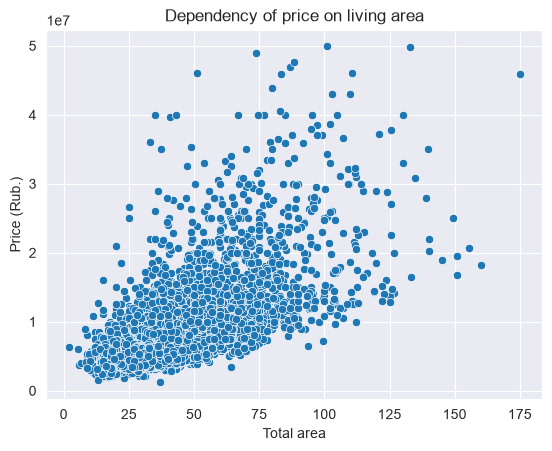

In [247]:
sns.scatterplot(data=filtered_data, x='living_area', y='last_price')
plt.title('Dependency of price on living area')
plt.xlabel('Total area')
plt.ylabel('Price (Rub.)')
plt.grid(True)
plt.show()

**<span style="color: green;">The chart shows a positive correlation between living area and apartment price — overall, as the living area increases, the price also grows.</span>**


**3. Kitchen area**

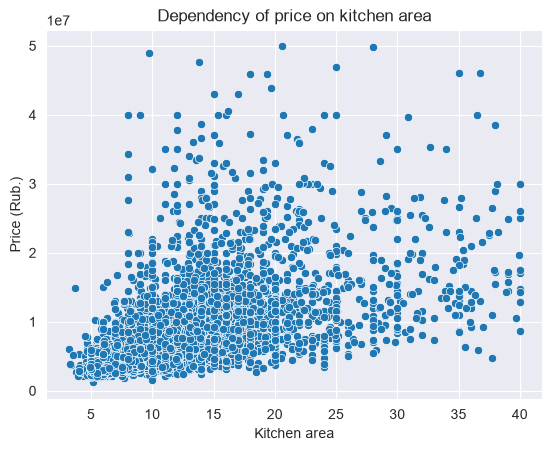

In [248]:
sns.scatterplot(data=filtered_data, x='kitchen_area', y='last_price')
plt.title('Dependency of price on kitchen area')
plt.xlabel('Kitchen area')
plt.ylabel('Price (Rub.)')
plt.grid(True)
plt.show()

**<span style="color: green;">There is no clear linear relationship between the kitchen area and the price. Although it can be noted that apartments with a larger kitchen are more often more expensive, the spread of values is very wide. Kitchen area has a weak impact on the apartment price compared to the total or living area. It serves more as an additional characteristic of comfort.
</span>**

**4. Number of rooms**

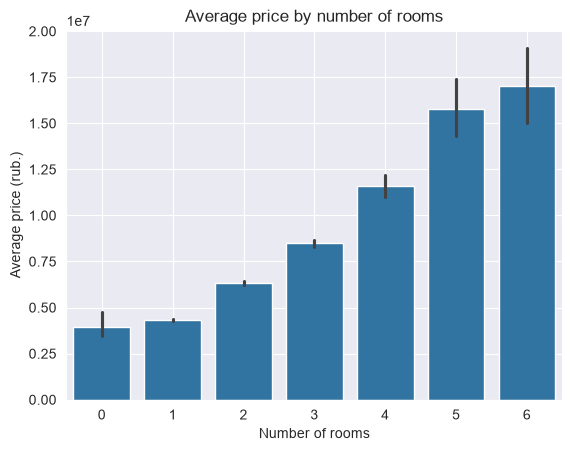

In [249]:
sns.barplot(data=filtered_data, x='rooms', y='last_price')
plt.title('Average price by number of rooms')
plt.xlabel('Number of rooms')
plt.ylabel('Average price (rub.)')
plt.grid(True)
plt.show()

**<span style="color: green;">The average apartment price increases as the number of rooms grows.
The more rooms there are, the higher the average cost of the property.</span>**

**A particularly noticeable price jump begins starting from 3 rooms and above — this may be due to the fact that multi-room apartments more often have a larger area, are located in more prestigious areas, or feature an improved layout.**

**However, it is worth noting that the price increase is not strictly linear — a sharp rise is visible for 5 and 6-room apartments.**


**5. Day of the week the listing was posted**

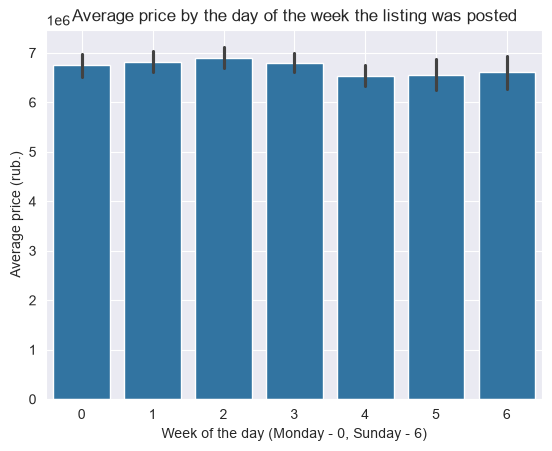

In [250]:
sns.barplot(data=filtered_data, x='weekday_exposition', y='last_price')
plt.title('Average price by the day of the week the listing was posted')
plt.xlabel('Week of the day (Monday - 0, Sunday - 6)')
plt.ylabel('Average price (rub.)')
plt.grid(True)
plt.show()

**<span style="color: green;">Based on the barplot, the day of the week the listing was posted has virtually no effect on the average apartment price. The variance is minimal, and all bars sit at roughly the same level—around 6.5 million rubles. This indicates that price is determined by other factors rather than the publication day.
</span>**

**6. The month the listing was posted**

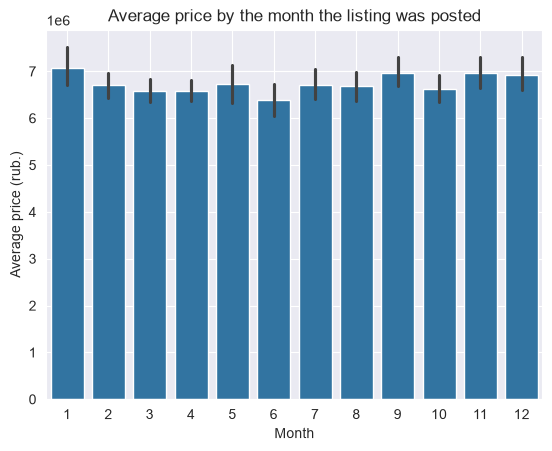

In [251]:
sns.barplot(data=filtered_data, x='month_exposition', y='last_price')
plt.title('Average price by the month the listing was posted')
plt.xlabel('Month')
plt.ylabel('Average price (rub.)')
plt.grid(True)
plt.show()

**<span style="color: green;">The chart shows that the month the listing was published has virtually no effect on the price. Minor fluctuations may be due to seasonal factors or random variations.</span>**

**7. The year the listing was posted**

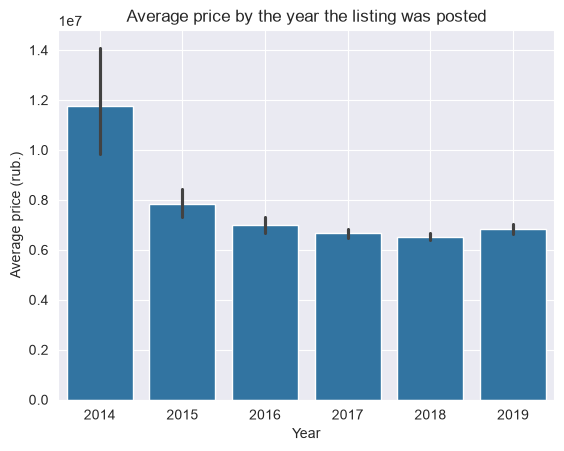

In [252]:
sns.barplot(data=filtered_data, x='year_exposition', y='last_price')
plt.title('Average price by the year the listing was posted')
plt.xlabel('Year')
plt.ylabel('Average price (rub.)')
plt.grid(True)
plt.show()

**<span style="color: green;">In this case, a more pronounced trend is observed: in 2014, the average price was noticeably higher, followed by a decline and stabilization at a level below 8 million rubles. This may be due to economic shifts and market fluctuations.</span>**

**8. Floor**

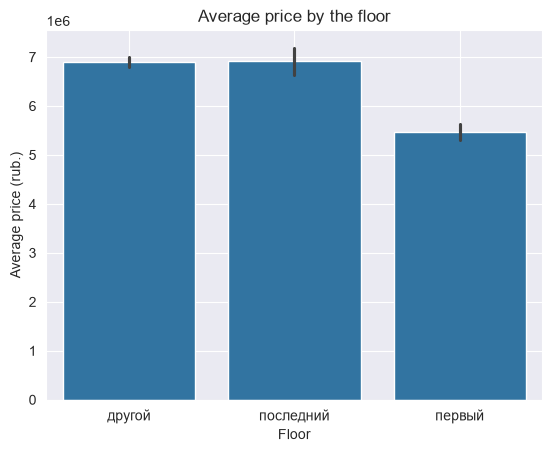

In [253]:
sns.barplot(data=filtered_data, x='floor_type', y='last_price')
plt.title('Average price by the floor')
plt.xlabel('Floor')
plt.ylabel('Average price (rub.)')
plt.grid(True)
plt.show()

**<span style="color: green;">Ground-floor apartments are noticeably cheaper. Prices are higher on the top and intermediate floors, especially the top floor—likely due to better views and quietness.</span>**

**9. 10 localities**

In [254]:
pivot_table = (
    filtered_data.groupby('locality_name')
    .agg(ads_count=('locality_name', 'count'),
         mean_price_per_sqm=('price_per_meter', 'mean'))
    .sort_values(by='ads_count', ascending=False)
    
)
top10 = pivot_table.head(10)
top10

,ads_count,mean_price_per_sqm
locality_name,,
Санкт-Петербург,9435,111812.058461
Пушкин,216,103136.483519
поселок Шушары,211,79215.832038
Колпино,201,76069.992736
поселок Парголово,137,90901.350730
Сестрорецк,126,101563.633333
Петергоф,117,84807.991880
Красное Село,104,73504.911250
поселок Металлострой,48,72899.403125


**<span style="color: green;">Highest price per $m^2$: Saint Petersburg — 111,099.15 RUB.</span>**

**<span style="color: red;">Lowest price per $m^2$: Strelna settlement — 88,266.44 RUB.</span>**



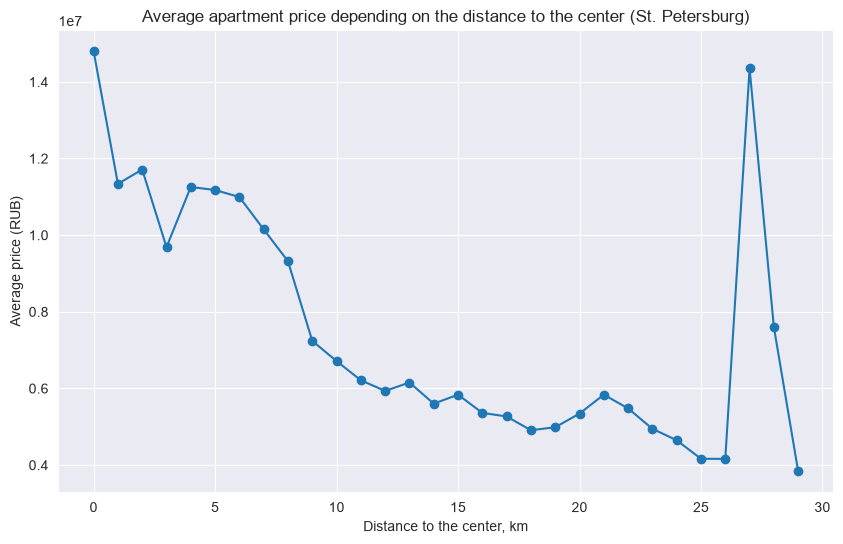

In [255]:

spb_flats = filtered_data[filtered_data["locality_name"] == "Санкт-Петербург"]
price_by_distance = spb_flats.groupby("city_center_km")["last_price"].mean()

plt.figure(figsize=(10, 6))
plt.plot(price_by_distance.index, price_by_distance.values, marker='o')
plt.title('Average apartment price depending on the distance to the center (St. Petersburg)')
plt.xlabel('Distance to the center, km')
plt.ylabel('Average price (RUB)')
plt.grid(True)
plt.show()

**<span style="color: green;">The closer an apartment is to the center of Saint Petersburg, the higher its average price—reaching its peak at zero distance and within 1 km. Beyond that, the value drops sharply, especially within the 5–10 km range, after which it stabilizes. This confirms a strong dependence of price on the distance to the center: central districts are the most expensive, while housing in the outskirts is significantly more affordable.</span>**



### Comprehensive summary

**<span style="color: green;">As part of the project, a comprehensive preprocessing and exploratory analysis of apartment sales data was carried out. Duplicates were eliminated, missing values processed, outliers corrected, and new features—such as price per square meter, distance to the center, and floor type—were added. This provided a deeper understanding of the patterns influencing housing costs.</span>**

- **The analysis results showed that the strongest impact on price comes from the total and living area of the apartment. The larger the area, the higher the price. To a lesser, yet significant degree, factors like distance to the city center, number of room counts, and the floor level also matter. Parameters such as kitchen area, day, or month of listing publication proved less impactful.**

- **Real estate prices predictably decrease as the distance from the center of Saint Petersburg increases—peaking within 3 km, after which they gradually decline and stabilize. It was also revealed that ground-floor apartments are cheaper, while top-floor units can command a higher price, likely due to better views and less noise.**

- **Sales speed also varies: the median sale time is 94 days, meaning half of the apartments sell within roughly three months. A quarter of the properties leave the market faster—in 43 days or less, which can be considered fast sales. Listings active longer than 227 days can be classified as prolonged.**

- **Overall, the analysis outlines the profile of a typical average apartment: an object with an area of about 50–60 m², a living zone within 30 m², and a kitchen around 10 m². Usually, such an apartment has 1–2 rooms, is located on a middle floor of a 5–10 story building, with ceiling heights ranging from 2.5 to 2.7 meters. It sits at a distance of 10–15 km from the city center, costs on average 4–6.5 million rubles, and takes about 1.5 to 3 months to sell.**